In [ ]:
# 检测图像阈值，MetaCloak模式
from torchvision import transforms
import torch
from pathlib import Path
from PIL import Image

def load_data(data_dir, size=512, center_crop=True) -> torch.Tensor:
    image_transforms = transforms.Compose(
        [
            transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(size) if center_crop else transforms.RandomCrop(size),
            transforms.ToTensor(),
            # transforms.Normalize([0.5], [0.5]),
        ]
    )

    images = [image_transforms(Image.open(i).convert("RGB")) for i in sorted(list(Path(data_dir).iterdir()))]
    images = torch.stack(images)
    return images

weight_type = torch.bfloat16
ori_dir = '/data1/humw/Datasets/VGGFace2/n000050/set_B'
ori_imgs = load_data(ori_dir).to(dtype=weight_type)

# 多模型集成
adv_dir0 = '/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/Encoder_attack_VGGFace2_vae15-ipadapter-photomaker_cosine_eot-0_yingbu/n000050'
adv_imgs0 = load_data(adv_dir0).to(dtype=weight_type)
et0 = adv_imgs0 - ori_imgs
# 只扰动VAE
adv_dir1 = "/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/Encoder_attack_VGGFace2_vae15_cosine_eot-0_yingbu/n000050"
adv_imgs1 = load_data(adv_dir1).to(dtype=weight_type)
et1 = adv_imgs1 - ori_imgs
# 只扰动IP-Adapter
adv_dir2 = "/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/Encoder_attack_VGGFace2_ipadapter_cosine_eot-0_yingbu/n000050"
adv_imgs2 = load_data(adv_dir2).to(dtype=weight_type)
et2 = adv_imgs2 - ori_imgs
# 只扰动PhotoMaker
adv_dir3 = "/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/Encoder_attack_VGGFace2_photomaker_cosine_eot-0_yingbu/n000050"
adv_imgs3 = load_data(adv_dir3).to(dtype=weight_type)
et3 = adv_imgs3 - ori_imgs

In [55]:
print("16/255:{}".format(16/255))

print("et0 min:{}".format(et0.min()))
print("et0 max:{}".format(et0.max()))
print("et0 mean:{}".format(et0.mean()))
print("et0 std:{}".format(et0.std()))

abs_et0 = abs(et0)
print("abs_et0 min:{}".format(abs_et0.min()))
print("abs_et0 max:{}".format(abs_et0.max()))
print("abs_et0 mean:{}".format(abs_et0.mean()))
print("abs_et0 std:{}".format(abs_et0.std()))

16/255:0.06274509803921569
et0 min:-0.064453125
et0 max:0.068359375
et0 mean:0.007049560546875
et0 std:0.04248046875
abs_et0 min:0.0
abs_et0 max:0.068359375
abs_et0 mean:0.037841796875
abs_et0 std:0.02099609375


In [56]:
print("16/255:{}".format(16/255))

print("et1 min:{}".format(et1.min()))
print("et1 max:{}".format(et1.max()))
print("et1 mean:{}".format(et1.mean()))
print("et1 std:{}".format(et1.std()))

abs_et1 = abs(et1)
print("abs_et1 min:{}".format(abs_et1.min()))
print("abs_et1 max:{}".format(abs_et1.max()))
print("abs_et1 mean:{}".format(abs_et1.mean()))
print("abs_et1 std:{}".format(abs_et1.std()))

16/255:0.06274509803921569
et1 min:-0.064453125
et1 max:0.068359375
et1 mean:0.01251220703125
et1 std:0.04443359375
abs_et1 min:0.0
abs_et1 max:0.068359375
abs_et1 mean:0.041259765625
abs_et1 std:0.020751953125


In [57]:
print("16/255:{}".format(16/255))

print("et2 min:{}".format(et2.min()))
print("et2 max:{}".format(et2.max()))
print("et2 mean:{}".format(et2.mean()))
print("et2 std:{}".format(et2.std()))

abs_et2 = abs(et2)
print("abs_et2 min:{}".format(abs_et2.min()))
print("abs_et2 max:{}".format(abs_et2.max()))
print("abs_et2 mean:{}".format(abs_et2.mean()))
print("abs_et2 std:{}".format(abs_et2.std()))

16/255:0.06274509803921569
et2 min:-0.064453125
et2 max:0.068359375
et2 mean:0.001556396484375
et2 std:0.0341796875
abs_et2 min:0.0
abs_et2 max:0.068359375
abs_et2 mean:0.0257568359375
abs_et2 std:0.0225830078125


In [58]:
print("16/255:{}".format(16/255))

print("et3 min:{}".format(et3.min()))
print("et3 max:{}".format(et3.max()))
print("et3 mean:{}".format(et3.mean()))
print("et3 std:{}".format(et3.std()))

abs_et3 = abs(et3)
print("abs_et3 min:{}".format(abs_et3.min()))
print("abs_et3 max:{}".format(abs_et3.max()))
print("abs_et3 mean:{}".format(abs_et3.mean()))
print("abs_et3 std:{}".format(abs_et3.std()))

16/255:0.06274509803921569
et3 min:-0.064453125
et3 max:0.068359375
et3 mean:0.00136566162109375
et3 std:0.0291748046875
abs_et3 min:0.0
abs_et3 max:0.068359375
abs_et3 mean:0.0213623046875
abs_et3 std:0.02001953125


### 计算扰动之间的余弦相似度

In [11]:
# 两两之间计算余弦相似度分数
import torch.nn.functional as F

# ensemble, vae15, IP-Adapter, PhotoMaker
ets = [et0, et1, et2, et3]
# 计算ets中所有元素的两两之间的余弦相似度，然后画出热力图
sims = []
for i in range(len(ets)):
    tmp = []
    for j in range(len(ets)):
        sim = F.cosine_similarity(ets[i], ets[j]).mean().item()
        print("i: {}, j: {} sim: {}".format(i, j, sim))
        tmp.append(sim)
    sims.append(tmp)
print(sims)

i: 0, j: 0 sim: 1.0
i: 0, j: 1 sim: 0.333984375
i: 0, j: 2 sim: 0.087890625
i: 0, j: 3 sim: 0.076171875
i: 1, j: 0 sim: 0.333984375
i: 1, j: 1 sim: 1.0
i: 1, j: 2 sim: 0.03369140625
i: 1, j: 3 sim: 0.021484375
i: 2, j: 0 sim: 0.087890625
i: 2, j: 1 sim: 0.03369140625
i: 2, j: 2 sim: 0.82421875
i: 2, j: 3 sim: 0.0732421875
i: 3, j: 0 sim: 0.076171875
i: 3, j: 1 sim: 0.021484375
i: 3, j: 2 sim: 0.0732421875
i: 3, j: 3 sim: 0.82421875
[[1.0, 0.333984375, 0.087890625, 0.076171875], [0.333984375, 1.0, 0.03369140625, 0.021484375], [0.087890625, 0.03369140625, 0.82421875, 0.0732421875], [0.076171875, 0.021484375, 0.0732421875, 0.82421875]]


In [27]:
# 对角线改成1
# 创建示例数据
models_x = ["ensemble", "vae15", "ipadapter", "photomaker"]
models_y = ["photomaker", "ipadapter", "vae15", "ensemble"]
sims = [
        [0.076171875, 0.021484375, 0.0732421875, 1.0], # photomaker
        [0.087890625, 0.03369140625, 1.0, 0.0732421875], # ipadapter
        [0.333984375, 1.0, 0.03369140625, 0.021484375], # vae15
        [1.0, 0.333984375, 0.087890625, 0.076171875], # ensemble
        ] 

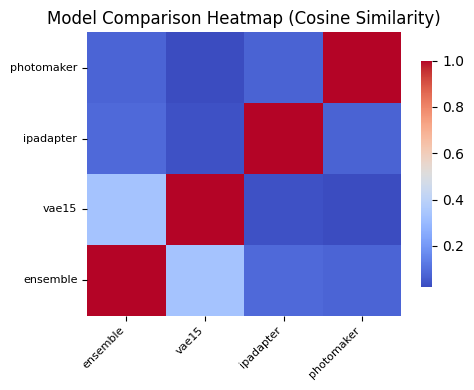

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 创建热图
plt.figure(figsize=(5, 4))
sns.heatmap(sims, annot=False, cmap="coolwarm", xticklabels=models_x, yticklabels=models_y, cbar_kws={"shrink": 0.8})

# 调整显示
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title("Model Comparison Heatmap (Cosine Similarity)")
plt.tight_layout()
plt.show()

### 分析
- 模型集成获取的扰动和单独扰动VAE15的扰动更为接近（所以VAE15效果还可以），与IP-Adapter和PhotoMaker的扰相似度很小（所以效果明显变差）
- 值得注意的是，ipadapter和photomaker获取的扰动之间的相似度很低，这表明这两种方法生成的扰动在语义空间上存在较大差异

### MSE

In [36]:
# 两两之间计算MSE距离（取负值，方便与余弦对比）
import torch.nn.functional as F

# ensemble, vae15, IP-Adapter, PhotoMaker
ets = [et0, et1, et2, et3]
# 计算ets中所有元素的两两之间的MSE距离，然后画出热力图
mses = []
for i in range(len(ets)):
    tmp = []
    for j in range(len(ets)):
        mse = - F.mse_loss(ets[i].float(), ets[j].float()).item()
        print("i: {}, j: {} mse: {}".format(i, j, mse))
        tmp.append(mse)
    mses.append(tmp)
print(mses)

i: 0, j: 0 mse: -0.0
i: 0, j: 1 mse: -0.0024791962932795286
i: 0, j: 2 mse: -0.0026998845860362053
i: 0, j: 3 mse: -0.0024615477304905653
i: 1, j: 0 mse: -0.0024791962932795286
i: 1, j: 1 mse: -0.0
i: 1, j: 2 mse: -0.0031861800234764814
i: 1, j: 3 mse: -0.0029286323115229607
i: 2, j: 0 mse: -0.0026998845860362053
i: 2, j: 1 mse: -0.0031861800234764814
i: 2, j: 2 mse: -0.0
i: 2, j: 3 mse: -0.001974246697500348
i: 3, j: 0 mse: -0.0024615477304905653
i: 3, j: 1 mse: -0.0029286323115229607
i: 3, j: 2 mse: -0.001974246697500348
i: 3, j: 3 mse: -0.0
[[-0.0, -0.0024791962932795286, -0.0026998845860362053, -0.0024615477304905653], [-0.0024791962932795286, -0.0, -0.0031861800234764814, -0.0029286323115229607], [-0.0026998845860362053, -0.0031861800234764814, -0.0, -0.001974246697500348], [-0.0024615477304905653, -0.0029286323115229607, -0.001974246697500348, -0.0]]


In [39]:
mses = [
    [-0.0024615477304905653, -0.0029286323115229607, -0.001974246697500348, -0.0], # ensemble
    [-0.0026998845860362053, -0.0031861800234764814, -0.0, -0.001974246697500348], # vae15
    [-0.0024791962932795286, -0.0, -0.0031861800234764814, -0.0029286323115229607], # ipadapter
    [-0.0, -0.0024791962932795286, -0.0026998845860362053, -0.0024615477304905653], # photomaker
    ]

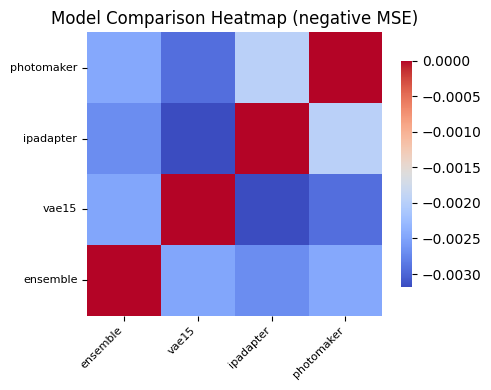

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 创建热图
plt.figure(figsize=(5, 4))
sns.heatmap(mses, annot=False, cmap="coolwarm", xticklabels=models_x, yticklabels=models_y, cbar_kws={"shrink": 0.8})

# 调整显示
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title("Model Comparison Heatmap (negative MSE)")
plt.tight_layout()
plt.show()

### 分析
- 可以发现，IP-Adapter和PhotoMaker之间的MSE距离还是比较接近的，猜测联合扰动IP-Adapter和PhotoMaker的效果会很好
- VAE15和两个CLIP编码器之间的MSE距离很大

In [1]:
import torch
import torch.nn as nn

# 初始化 CosineSimilarity 对象
cosine_similarity = nn.CosineSimilarity(dim=1, eps=1e-8)

# 创建两个示例张量
tensor1 = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
tensor2 = torch.tensor([[4.0, 6.0], [2.0, 3.0]])

# 计算余弦相似度
similarity = cosine_similarity(tensor1, tensor2)

print(similarity)

/data1/humw/anaconda3/envs/anti-dreambooth/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tensor([0.9923, 0.9985])
